---
## Part 1. 머신러닝과 scikit-learn 소개

## 머신러닝이란?
사람이 규칙을 직접 코딩하지 않고, **데이터로부터 규칙을 학습해** 새로운 데이터를 예측/분류하는 방법입니다.

- 규칙 프로그래밍: `"제목에 '광고' 포함 → 스팸"` 처럼 사람이 규칙을 작성
- 머신러닝: 과거 수십만 건의 메일 데이터를 보고 **스스로** 스팸 패턴을 학습

## 머신러닝의 주요 종류
1) **지도학습(Supervised)** — 정답(y)이 있음
   - **분류**: 스팸/정상, 양성/음성 (라벨 예측)
   - **회귀**: 집값/매출/보험료 (숫자 예측)
2) **비지도학습(Unsupervised)** — 정답 없음
   - **군집화**: 고객 세그멘테이션
   - **차원축소**: 시각화/압축(PCA 등)
3) **강화학습(Reinforcement)** — 보상 기반 의사결정(게임/로보틱스)

## 용어 정리
- **Feature(특성, X)**: 모델이 입력으로 받는 정보(예: 전재산, 혈액형, 건강검진기록).
- **Label/Target(정답, y)**: 모델이 맞추려는 값(예: 생존 여부, 암 양성/음성).
- **Estimator(추정기)**: `fit/predict`를 제공하는 모델/전처리기(예: LogisticRegression, StandardScaler).
- **Transformer(변환기)**: `fit/transform`으로 데이터를 바꾸는 전처리기(예: StandardScaler, OneHotEncoder).
- **Pipeline**: 전처리 + 모델을 한 줄로 묶어 "훈련에만 fit, 시험엔 transform"을 자동으로 지키게 하는 래퍼.
- **Metric(평가지표)**: 성능을 숫자로 표현(분류: Accuracy/F1/ROC-AUC, 회귀: RMSE/MAE/R²).

## 생활 속 사례
- 스팸메일 필터
- 추천 시스템(넷플릭스/유튜브)
- 질병 진단 보조(당뇨/암)
- 자율주행 인식

메시지: *여러분은 이미 매일 ML을 사용하고 있습니다.*

## 머신러닝 프로젝트 흐름
1. **데이터 준비**
2. **학습/시험 데이터 분리** *(Train/Test)*
3. **모델 학습** `fit(X_train, y_train)`
4. **예측** `predict(X_test)`
5. **평가** *(metrics: 분류=정확도/F1/ROC 등, 회귀=MAE/RMSE/R²)*
6. **개선** *(튜닝, 전처리, 더 나은 모델)*

> **비유**: 같은 문제로 공부하고 같은 문제로 시험 보면 **성적이 뻥튀기**됨
> 그래서 **Train/Test**를 나눠 *처음 보는 문제*로 실력을 확인해야 함

## scikit-learn 이란?
파이썬의 **머신러닝 표준 라이브러리**(2007 시작). 교육/실무 모두에서 가장 널리 쓰임

- **일관된 API(사용방법)**: `fit → predict → score` (모델이 달라도 동일한 사용법)
- 알고리즘(분류/회귀/군집화), **전처리**, **모델 선택(CV/GridSearch)**, **평가 지표**까지 원스톱
- 문서/예제가 풍부하고 커뮤니티가 큼

**오늘의 포인트**: *모델을 바꿔도 `fit→predict→score` 패턴은 같음!*

## 환경/버전 확인
아래 셀을 실행해 현재 환경 버전을 기록해 둡니다.

나중에 같은 결과를 재현하고 환경 차이로 인한 오류를 줄이기 위해 버전을 기록합니다.

In [1]:
import sklearn, numpy as np, pandas as pd
import matplotlib, seaborn

print(f'sklearn: {sklearn.__version__}')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {seaborn.__version__}')

sklearn: 1.6.1
numpy: 2.3.3
pandas: 2.3.2
matplotlib: 3.10.6
seaborn: 0.13.2


## 한 장 요약 (오늘 이것만 기억)
1) ML = 코딩이 아니라 **데이터로 규칙을 학습**
2) 모든 모델은 **`fit → predict → score`**
3) **Train/Test**를 나눠야 성적이 뻥튀기되지 않음
4) 전처리는 **훈련에만 fit**, 시험엔 transform → **Pipeline**
5) 분류는 **Accuracy+F1/ROC-AUC**, 회귀는 **RMSE/MAE/R²**
6) 실무는 **교차검증(K-Fold)**으로 평균 성능을 본다

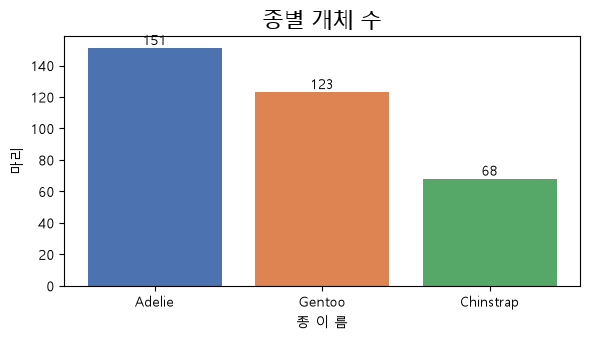

In [ ]:

# 폰트 준비
import platform
# 운영체제를 확인하여 폰트 자동 지정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')


import matplotlib.pyplot as plt # 그래프 그리기

x_axis = ['Adelie', 'Gentoo', 'Chinstrap']
y_axis = [151, 123, 68]

# 막대그래프로
plt.figure(figsize=(6, 3.5)) #도화지 
plt.bar( x_axis, y_axis , color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("종별 개체 수", size=15)
plt.ylabel("마리")
plt.xlabel("종 이 름")

# 막대 위에 숫자를 직접 적어 주면 읽기 편함
for i, v in enumerate([151, 123, 68]):  #enumerate() 인덱스 i와 값 v를 동시에 꺼내주는 함수
    plt.text(i, v + 2, str(v), ha="center") 
    #plt.text(x좌표, y좌표, 표시할 문자열, 옵션) #
    # i: x축 위치  
    # v + 2: y축 위치입니다. 값 v보다 조금 높은 곳에 글자를 찍기
    # str(v): 실제로 그래프에 적힐 내용
    # ha="center": 수평 정렬

plt.tight_layout()  # 제목, 축 레이블, 눈금, 서브플롯 간격이 서로 겹치지 않도록 레이아웃을 자동으로 조정
plt.show()

In [11]:
peng[peng["species"] == 'Adelie'] 

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
146,Adelie,Dream,36.6,18.4,184.0,3475.0,Female
147,Adelie,Dream,36.0,17.8,195.0,3450.0,Female
148,Adelie,Dream,37.8,18.1,193.0,3750.0,Male
149,Adelie,Dream,36.0,17.1,187.0,3700.0,Female


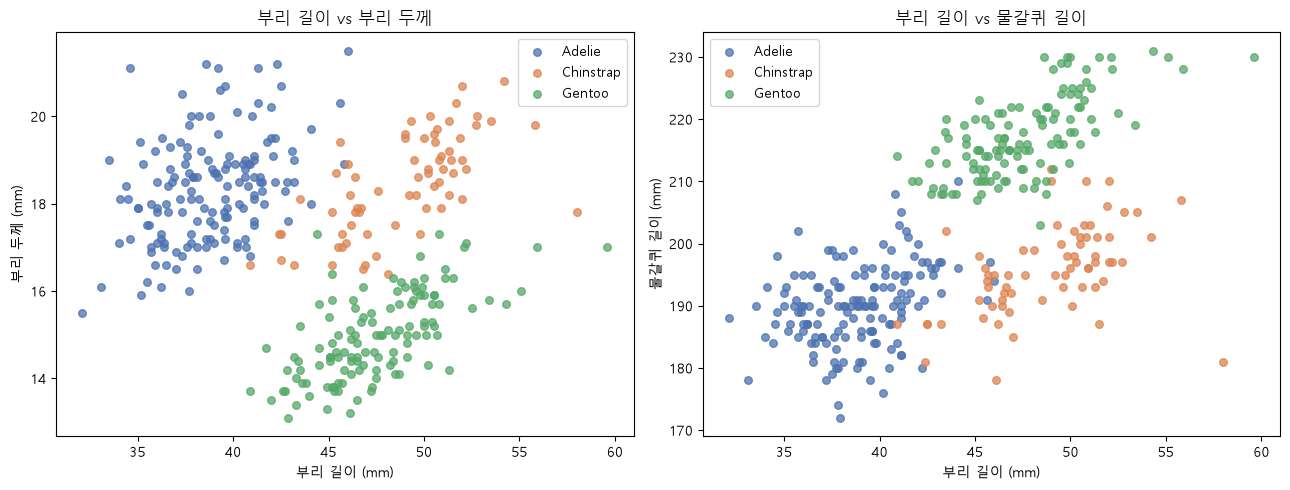

In [ ]:

        # 폰트 준비
        import platform
        # 운영체제를 확인하여 폰트 자동 지정
        if platform.system() == 'Windows':
            plt.rc('font', family='Malgun Gothic')
        elif platform.system() == 'Darwin':  # Mac 환경
            plt.rc('font', family='Apple SD Gothic Neo')

        import numpy as np              # 숫자 계산 (조건에 따라 값 고르기 등)
        import pandas as pd             # 표 형태 데이터 다루기
        import seaborn as sns           # 펭귄 데이터를 불러오는 용도로만 사용
        import matplotlib.pyplot as plt # 그래프 그리기

        peng_raw = sns.load_dataset("penguins")
        meas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
        peng = peng_raw.dropna(subset=meas).reset_index(drop=True)

        # 종마다 다른 색을 쓰기 위해 색을 미리 정해 둡니다.
        colors = {"Adelie": "#4C72B0", "Chinstrap": "#DD8452", "Gentoo": "#55A868"}

        # 1행 2열로 그래프 두 개를 나란히 그립니다.
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        # 종별로 데이터를 잘라서, 각각 다른 색으로 점을 찍습니다.
        for sp in ["Adelie", "Chinstrap", "Gentoo"]:
            sub = peng[peng["species"] == sp]   # 그 종만 골라내기

            # 왼쪽: 부리 길이 vs 부리 두께
            axes[0].scatter(sub["bill_length_mm"], sub["bill_depth_mm"],
                            label=sp, color=colors[sp], alpha=0.75, s=30)

            # 오른쪽: 부리 길이 vs 물갈퀴 길이
            axes[1].scatter(sub["bill_length_mm"], sub["flipper_length_mm"],
                            label=sp, color=colors[sp], alpha=0.75, s=30)

        axes[0].set_xlabel("부리 길이 (mm)")
        axes[0].set_ylabel("부리 두께 (mm)")
        axes[0].set_title("부리 길이 vs 부리 두께")
        axes[0].legend()

        axes[1].set_xlabel("부리 길이 (mm)")
        axes[1].set_ylabel("물갈퀴 길이 (mm)")
        axes[1].set_title("부리 길이 vs 물갈퀴 길이")
        axes[1].legend()

        plt.tight_layout()
        plt.show()


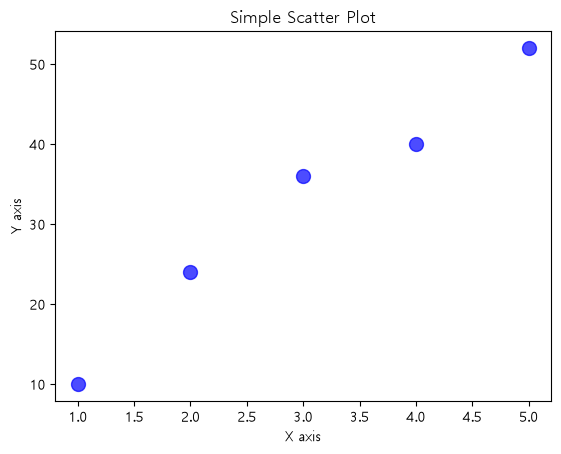

In [ ]:


        import matplotlib.pyplot as plt

        x_axis = [1, 2, 3, 4, 5]
        y_axis = [10, 24, 36, 40, 52]

        plt.scatter(x_axis, y_axis, color='blue', s=100, alpha=0.7)
        plt.title('Simple Scatter Plot')
        plt.xlabel('X axis')
        plt.ylabel('Y axis')
        plt.show()



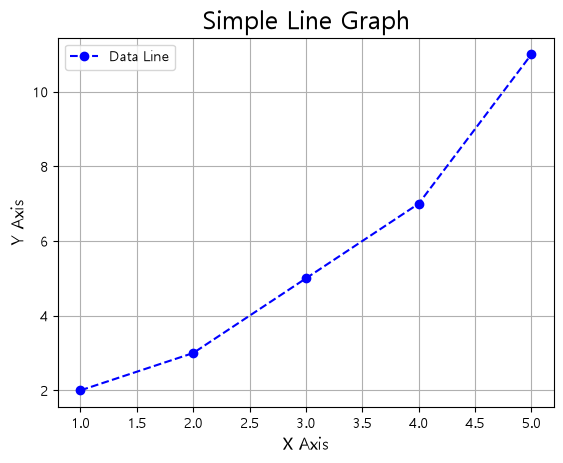

In [17]:
        # 폰트 준비
        import platform
        # 운영체제를 확인하여 폰트 자동 지정
        if platform.system() == 'Windows':
            plt.rc('font', family='Malgun Gothic')
        elif platform.system() == 'Darwin':  # Mac 환경
            plt.rc('font', family='Apple SD Gothic Neo')

        #그래프
        import matplotlib.pyplot as plt

        x = [1, 2, 3, 4, 5]
        y = [2, 3, 5, 7, 11]

        plt.plot(x, y, color='blue', marker='o', linestyle='--', label='Data Line')
        plt.title('Simple Line Graph' , size=18)
        plt.xlabel('X Axis', size=12)
        plt.ylabel('Y Axis', size=12)
        plt.legend()
        plt.grid(True)
        plt.show()